<a href="https://colab.research.google.com/github/Tarteel89/Prediction-of-Product-Sales/blob/main/Sales%20prediction%204.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading Data

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [54]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [55]:
fname='/content/drive/MyDrive/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv'
df=pd.read_csv(fname)
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


##Summary the DataFrame's columns

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [57]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


##Data Cleaning

###how many rows & columns

In [58]:
df.shape

(8523, 12)

###the datatypes of each variable

In [59]:
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


###check if there duplicates

In [60]:
df.duplicated().sum()

np.int64(0)

###Identify missing values

In [61]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [62]:
df.isna().sum() / len(df) * 100

,0
Item_Identifier,0.000000
Item_Weight,17.165317
Item_Fat_Content,0.000000
Item_Visibility,0.000000
Item_Type,0.000000
Item_MRP,0.000000
Outlet_Identifier,0.000000
Outlet_Establishment_Year,0.000000
Outlet_Size,28.276428
Outlet_Location_Type,0.000000


###Address the missing Values by using a placeholder

In [63]:
df['Outlet_Size']=df.fillna({'Outlet_Size': 'MISSING'}, inplace=True)

In [64]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,8523
Outlet_Location_Type,0


In [65]:
df.fillna({'Item_Weight':'mean'},inplace=True)

###Confirm that no more missing values

In [66]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,8523
Outlet_Location_Type,0


###Fix in consistent categories of data

In [67]:
df['Item_Fat_Content']=df['Item_Fat_Content'].replace({'LF':'Low Fat','low fat':'Low Fat','reg':'Regular'})
df['Item_Fat_Content']

,Item_Fat_Content
0,Low Fat
1,Regular
2,Low Fat
3,Regular
4,Low Fat
...,...
8518,Low Fat
8519,Regular
8520,Low Fat
8521,Regular


In [68]:
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


###obtain summary statistics

In [69]:
df.describe().loc[['min','max','mean']]

,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
min,0.000000,31.290000,1985.000000,33.290000
max,0.328391,266.888400,2009.000000,13086.964800
mean,0.066132,140.992782,1997.831867,2181.288914


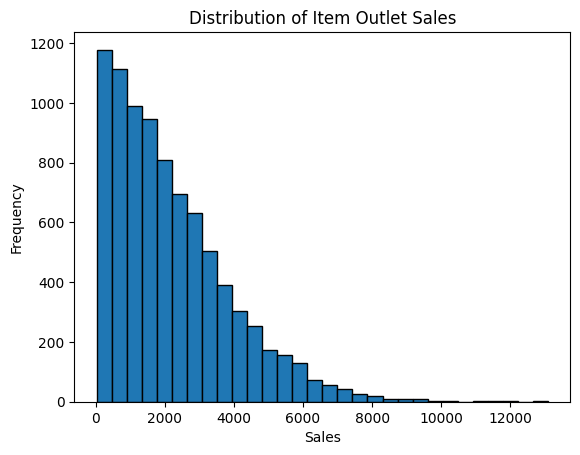

In [70]:
plt.hist(df['Item_Outlet_Sales'],bins=30,edgecolor='Black')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.title('Distribution of Item Outlet Sales')
plt.savefig('histogram.png')

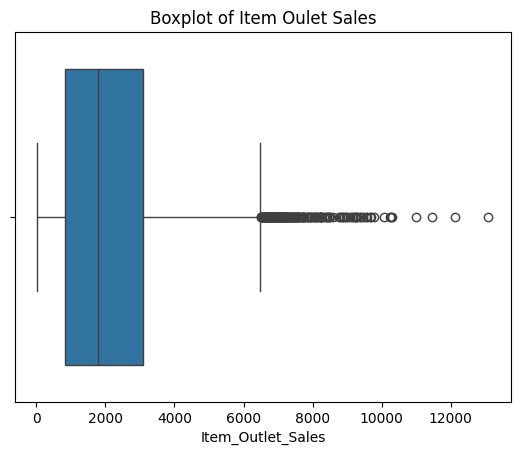

In [71]:
sns.boxplot(x=df['Item_Outlet_Sales'])
plt.title('Boxplot of Item Oulet Sales');
plt.savefig('boxplot.png')

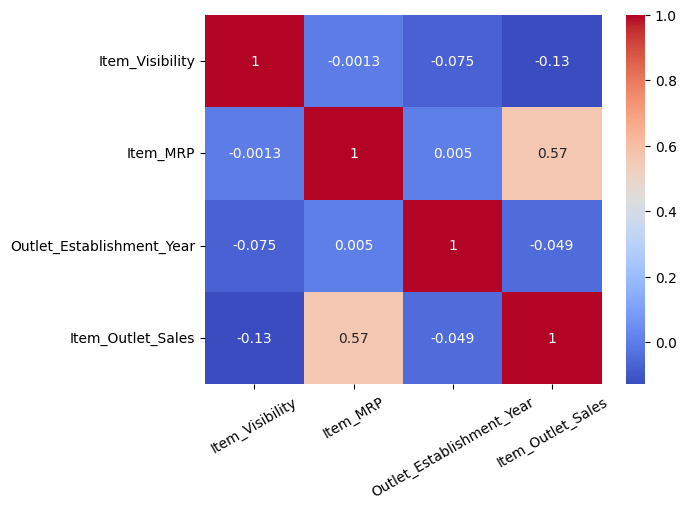

In [72]:
corr=df.corr(numeric_only=True)
ax=sns.heatmap(corr,annot=True,cmap='coolwarm');
ax.tick_params(axis='x',rotation=30)
plt.savefig('heatmap.png')

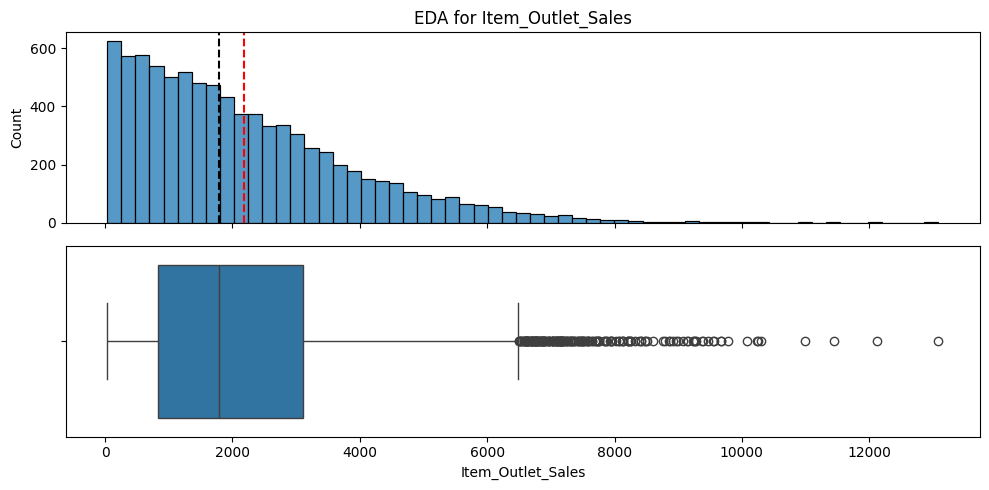

In [73]:
fig, axes = plt.subplots(nrows=2, figsize=(10,5), sharex=True)
sns.histplot(data=df,x = 'Item_Outlet_Sales',ax = axes[0])
mean_value = df['Item_Outlet_Sales'].mean()
axes[0].axvline(mean_value,color='red', ls='--',
           label=f"Mean Value = ${mean_value:,.2f}",);

med_value = df['Item_Outlet_Sales'].median()
axes[0].axvline(med_value,color='black', ls='--',
           label=f"Median Value = ${med_value:,.2f}");
sns.boxplot(data=df, x = 'Item_Outlet_Sales', ax = axes[1])

axes[0].set_title(f'EDA for {'Item_Outlet_Sales'}')

plt.tight_layout()
plt.savefig('EDA.png')

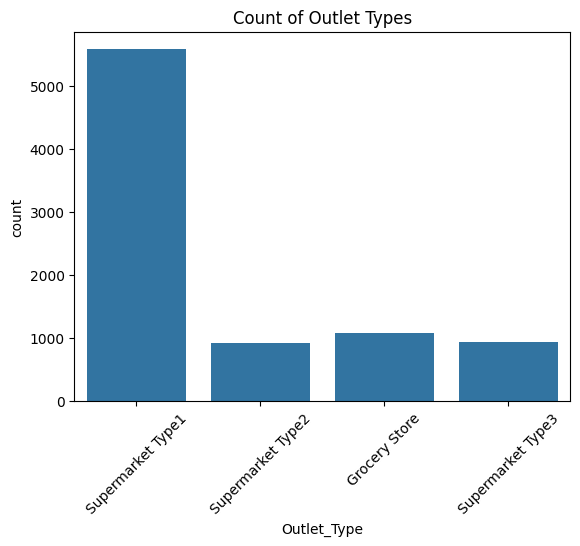

In [74]:
sns.countplot(x='Outlet_Type',data=df)
plt.xticks(rotation=45)
plt.title('Count of Outlet Types');
plt.savefig('countplot.png')

# Part 4 – Feature Inspection

> **Goal:** Inspect every feature for null values, distribution, cardinality, and predictive potential so we can make informed data-preparation decisions before modelling.

### Step 0 – Replace placeholders with real null values

In [75]:
# Replace the placeholder strings added in Week 2 with actual NaN values
import numpy as np

df['Outlet_Size']  = df['Outlet_Size'].replace('MISSING', np.nan)
df['Item_Weight']  = df['Item_Weight'].replace('mean',    np.nan)

print("Null counts after restoring NaNs:")
print(df.isnull().sum())

Null counts after restoring NaNs:
Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  8523
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


/tmp/ipykernel_2703/737348286.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Item_Weight']  = df['Item_Weight'].replace('mean',    np.nan)


--
## Feature 1 – Item_Identifier

**Data Dictionary:**  
Unique product ID assigned to each item (e.g. `FD032`, `DR011`). This is a nominal label, not a measurement.

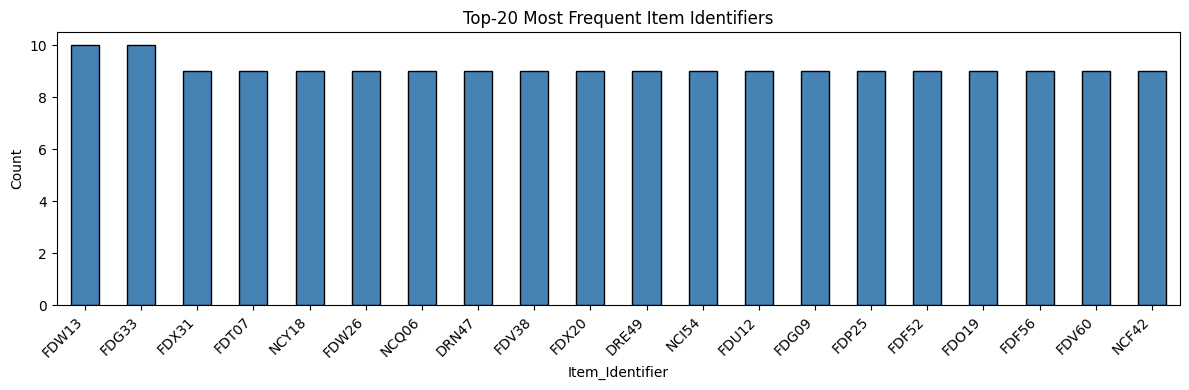

In [76]:
# ── Univariate visualisation ──────────────────────────────────────────────
top20 = df['Item_Identifier'].value_counts().head(20)
plt.figure(figsize=(12, 4))
top20.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top-20 Most Frequent Item Identifiers')
plt.xlabel('Item_Identifier')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feat_Item_Identifier_univariate.png')
plt.show()

### Univariate inspection – `Item_Identifier`

| Question | Answer |
|---|---|
| **Type** | Categorical – Nominal |
| **Null values** | 0 (0 %) |
| **Constant / quasi-constant?** | No |
| **Cardinality** | ~1 559 unique codes → **HIGH (> 10)** |
| **Known before target?** | Yes – assigned at stock entry |
| **Business reason to exclude?** | Yes – it is a unique ID, not a measurable property. Using it would cause overfitting. |

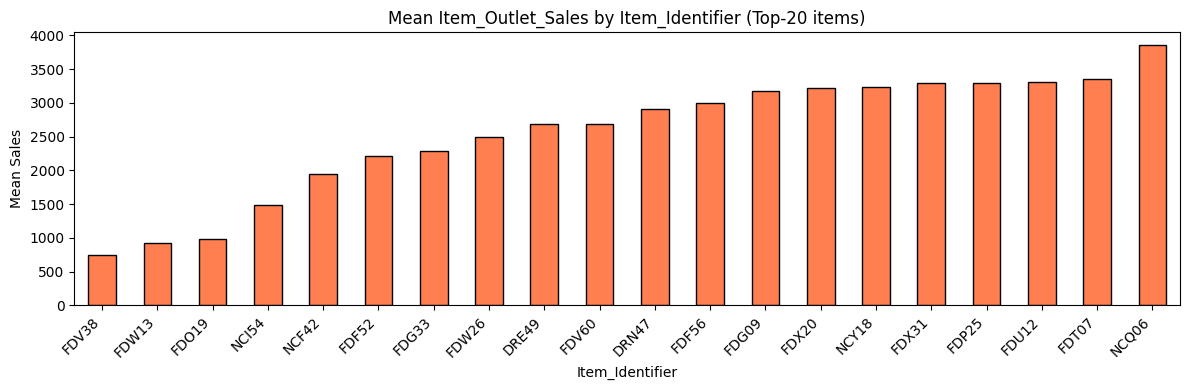

In [77]:
# ── Multivariate: mean sales per Item_Identifier (top 20) ─────────────────
top20_ids = df['Item_Identifier'].value_counts().head(20).index
df_top = df[df['Item_Identifier'].isin(top20_ids)]
means = df_top.groupby('Item_Identifier')['Item_Outlet_Sales'].mean().sort_values()

plt.figure(figsize=(12, 4))
means.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Mean Item_Outlet_Sales by Item_Identifier (Top-20 items)')
plt.ylabel('Mean Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feat_Item_Identifier_multivariate.png')
plt.show()

### Multivariate inspection – `Item_Identifier`

| Question | Answer |
|---|---|
| **Expected to predict sales?** | Unlikely – it is an arbitrary ID, not a meaningful signal |
| **Does it appear to predict sales?** | Some variation exists, but this is noise / data leakage risk |
| **Decision** | **Exclude** – drop before modelling |

---
## Feature 2 – `Item_Weight`

**Data Dictionary:**  
Weight of the product in kilograms. A continuous numeric feature.

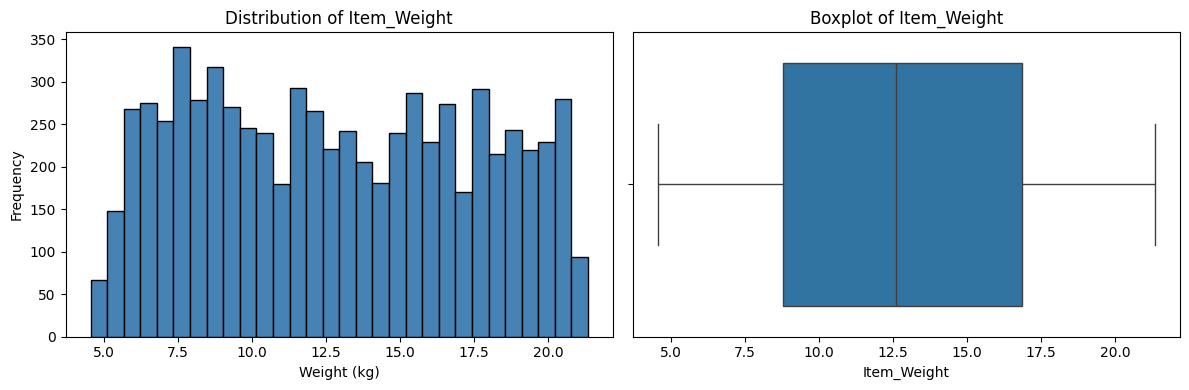

Null count: 1463 (17.2%)


In [78]:
# ── Univariate visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Item_Weight'].dropna(), bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Item_Weight')
axes[0].set_xlabel('Weight (kg)')
axes[0].set_ylabel('Frequency')

sns.boxplot(x=df['Item_Weight'], ax=axes[1])
axes[1].set_title('Boxplot of Item_Weight')
plt.tight_layout()
plt.savefig('feat_Item_Weight_univariate.png')
plt.show()

nulls = df['Item_Weight'].isnull().sum()
pct   = nulls / len(df) * 100
print(f"Null count: {nulls} ({pct:.1f}%)")

### Univariate inspection – `Item_Weight`

| Question | Answer |
|---|---|
| **Type** | Numeric – Continuous |
| **Null values** | ~2 439 (~17 %) |
| **How to handle nulls?** | **Impute with median** – distribution is roughly symmetric; median is robust to outliers |
| **Constant / quasi-constant?** | No |
| **Cardinality** | Continuous – N/A |
| **Known before target?** | Yes |
| **Business reason to exclude?** | No |

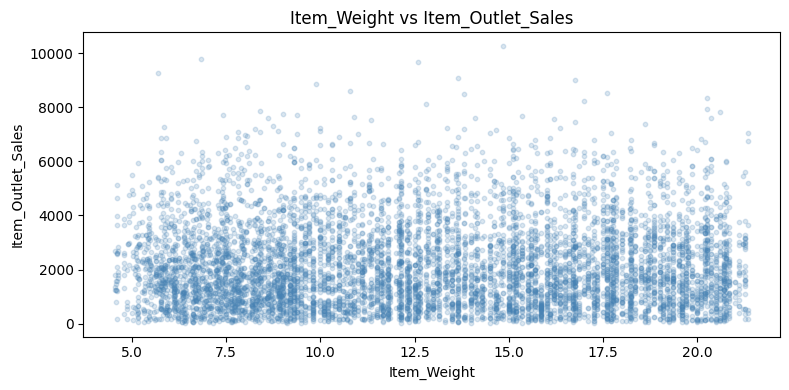

In [79]:
# ── Multivariate: scatter vs sales ────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.scatter(df['Item_Weight'], df['Item_Outlet_Sales'], alpha=0.2, color='steelblue', s=10)
plt.title('Item_Weight vs Item_Outlet_Sales')
plt.xlabel('Item_Weight')
plt.ylabel('Item_Outlet_Sales')
plt.tight_layout()
plt.savefig('feat_Item_Weight_multivariate.png')
plt.show()

### Multivariate inspection – `Item_Weight`

| Question | Answer |
|---|---|
| **Expected to predict sales?** | Weak signal – heavier items may sell differently |
| **Does it appear to predict sales?** | No clear linear trend visible in scatter |
| **Decision** | **Keep** – impute with median; may contribute marginally |

---
## Feature 3 – `Item_Fat_Content`

**Data Dictionary:**  
Fat content of the product. Categorical – two classes: `Low Fat` and `Regular`. (Inconsistent entries have already been standardised.)

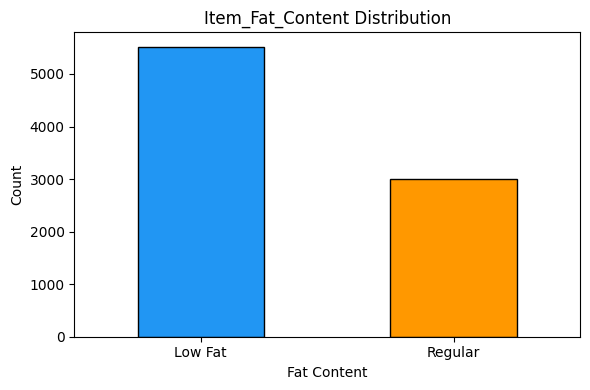

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64
Nulls: 0


In [80]:
# ── Univariate visualisation ──────────────────────────────────────────────
df['Item_Fat_Content'].value_counts().plot(kind='bar', color=['#2196F3','#FF9800'],
                                            edgecolor='black', figsize=(6, 4))
plt.title('Item_Fat_Content Distribution')
plt.xlabel('Fat Content')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('feat_Item_Fat_Content_univariate.png')
plt.show()

print(df['Item_Fat_Content'].value_counts())
print(f"Nulls: {df['Item_Fat_Content'].isnull().sum()}")

### Univariate inspection – `Item_Fat_Content`

| Question | Answer |
|---|---|
| **Type** | Categorical – Nominal (binary) |
| **Null values** | 0 (0 %) |
| **Constant / quasi-constant?** | No – both classes present |
| **Cardinality** | 2 – **LOW** |
| **Known before target?** | Yes |
| **Business reason to exclude?** | No |

/tmp/ipykernel_2703/1959284049.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Item_Fat_Content', y='Item_Outlet_Sales', data=df, palette='Set2')


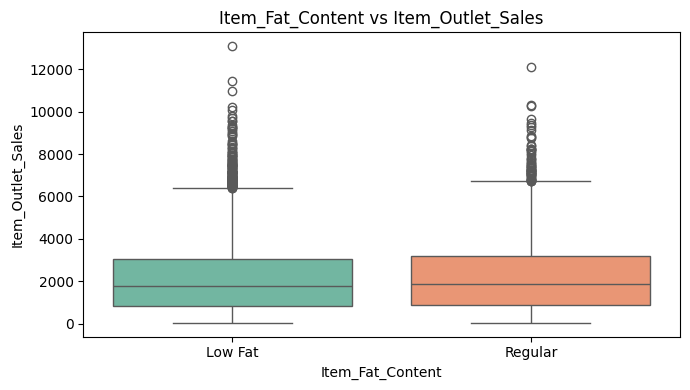

In [81]:
# ── Multivariate: box plot vs sales ───────────────────────────────────────
plt.figure(figsize=(7, 4))
sns.boxplot(x='Item_Fat_Content', y='Item_Outlet_Sales', data=df, palette='Set2')
plt.title('Item_Fat_Content vs Item_Outlet_Sales')
plt.tight_layout()
plt.savefig('feat_Item_Fat_Content_multivariate.png')
plt.show()

### Multivariate inspection – `Item_Fat_Content`

| Question | Answer |
|---|---|
| **Expected to predict sales?** | Possibly – health-conscious shoppers may prefer low-fat items |
| **Does it appear to predict sales?** | Distributions largely overlap; weak signal |
| **Decision** | **Keep** – encode with label/one-hot encoding |

---
## Feature 4 – `Item_Visibility`

**Data Dictionary:**  
The percentage of total display area in a store allocated to this product (0–1). A continuous numeric feature.

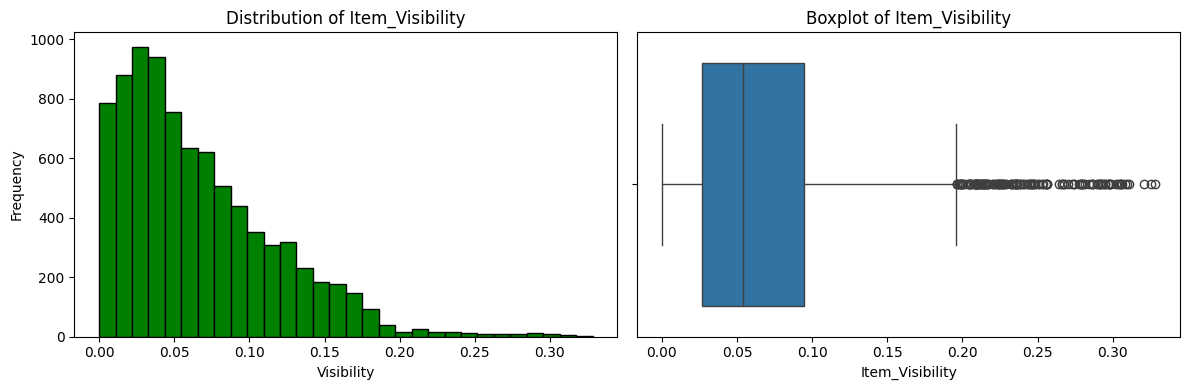

Nulls: 0
Zeros: 526 – likely data-entry placeholders


In [82]:
# ── Univariate visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Item_Visibility'], bins=30, color='green', edgecolor='black')
axes[0].set_title('Distribution of Item_Visibility')
axes[0].set_xlabel('Visibility')
axes[0].set_ylabel('Frequency')

sns.boxplot(x=df['Item_Visibility'], ax=axes[1])
axes[1].set_title('Boxplot of Item_Visibility')
plt.tight_layout()
plt.savefig('feat_Item_Visibility_univariate.png')
plt.show()

print(f"Nulls: {df['Item_Visibility'].isnull().sum()}")
print(f"Zeros: {(df['Item_Visibility']==0).sum()} – likely data-entry placeholders")

### Univariate inspection – `Item_Visibility`

| Question | Answer |
|---|---|
| **Type** | Numeric – Continuous |
| **Null values** | 0 (0 %) |
| **Note** | Many zeros (~13 %) are likely missing values entered as 0 |
| **Constant / quasi-constant?** | No |
| **Cardinality** | Continuous – N/A |
| **Known before target?** | Yes |
| **Business reason to exclude?** | No |

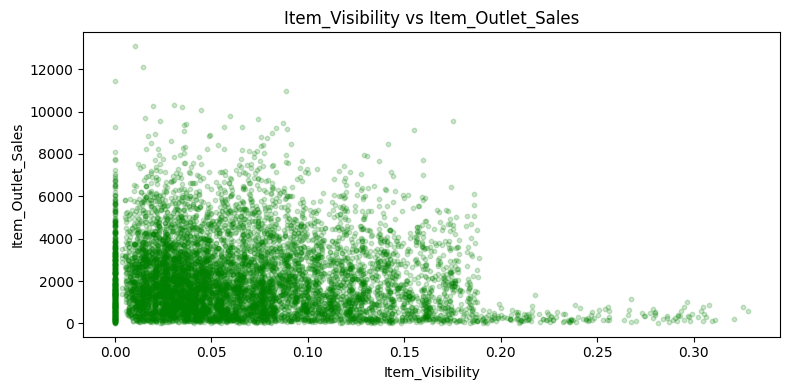

In [83]:
# ── Multivariate: scatter vs sales ────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.scatter(df['Item_Visibility'], df['Item_Outlet_Sales'], alpha=0.2, color='green', s=10)
plt.title('Item_Visibility vs Item_Outlet_Sales')
plt.xlabel('Item_Visibility')
plt.ylabel('Item_Outlet_Sales')
plt.tight_layout()
plt.savefig('feat_Item_Visibility_multivariate.png')
plt.show()

### Multivariate inspection – `Item_Visibility`

| Question | Answer |
|---|---|
| **Expected to predict sales?** | Yes – more visible items are seen more → more purchases |
| **Does it appear to predict sales?** | Slight negative trend after zero cluster; zeros should be re-coded to NaN then imputed |
| **Decision** | **Keep** – replace zeros with NaN, impute with median by item type |

---
## Feature 5 – `Item_Type`

**Data Dictionary:**  
The category of the product (e.g. Dairy, Soft Drinks, Meat, Fruits and Vegetables). A nominal categorical feature.

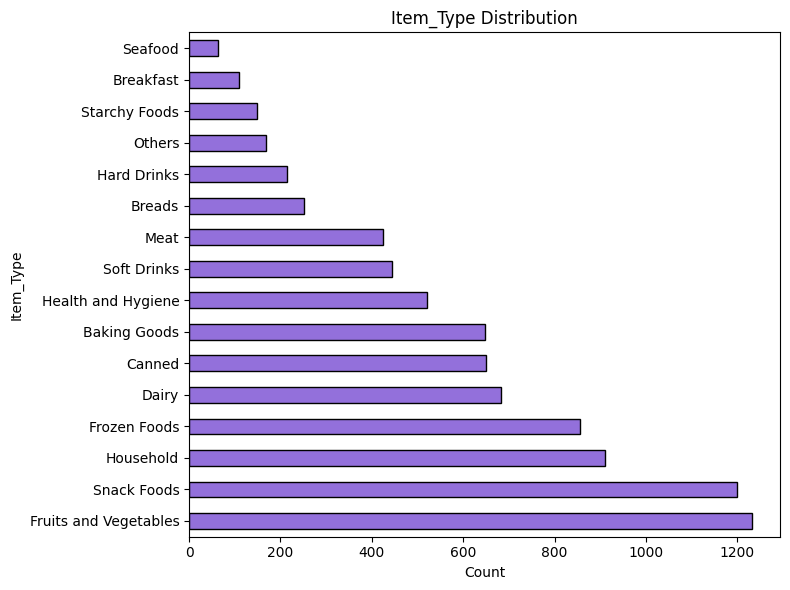

Unique categories: 16
Nulls: 0


In [84]:
# ── Univariate visualisation ──────────────────────────────────────────────
df['Item_Type'].value_counts().plot(kind='barh', color='mediumpurple',
                                     edgecolor='black', figsize=(8, 6))
plt.title('Item_Type Distribution')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('feat_Item_Type_univariate.png')
plt.show()

print(f"Unique categories: {df['Item_Type'].nunique()}")
print(f"Nulls: {df['Item_Type'].isnull().sum()}")

### Univariate inspection – `Item_Type`

| Question | Answer |
|---|---|
| **Type** | Categorical – Nominal |
| **Null values** | 0 (0 %) |
| **Constant / quasi-constant?** | No |
| **Cardinality** | 16 – **HIGH (> 10)** |
| **Known before target?** | Yes |
| **Business reason to exclude?** | No – item category is a meaningful business grouping |

/tmp/ipykernel_2703/522258576.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Item_Type', y='Item_Outlet_Sales', data=df, order=order, palette='tab20')


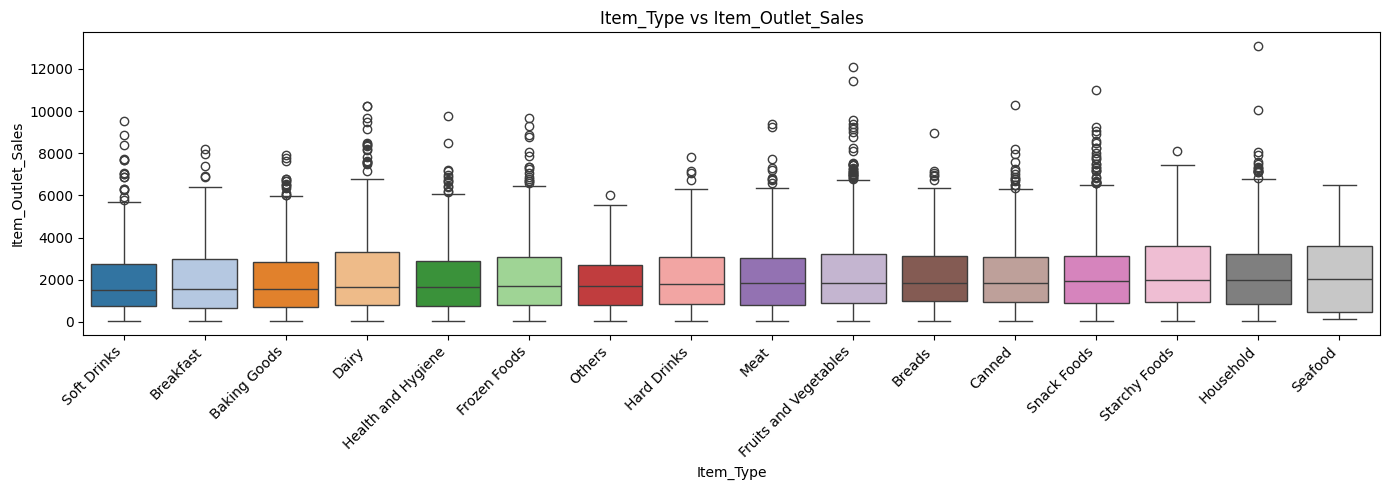

In [85]:
# ── Multivariate: box plot vs sales ───────────────────────────────────────
plt.figure(figsize=(14, 5))
order = df.groupby('Item_Type')['Item_Outlet_Sales'].median().sort_values().index
sns.boxplot(x='Item_Type', y='Item_Outlet_Sales', data=df, order=order, palette='tab20')
plt.title('Item_Type vs Item_Outlet_Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feat_Item_Type_multivariate.png')
plt.show()

### Multivariate inspection – `Item_Type`

| Question | Answer |
|---|---|
| **Expected to predict sales?** | Yes – different product categories have different demand profiles |
| **Does it appear to predict sales?** | Yes – visible median differences across categories |
| **Decision** | **Keep** – consider grouping into broader categories to reduce cardinality |

---
## Feature 6 – `Item_MRP`

**Data Dictionary:**  
Maximum Retail Price (list price) of the product in currency units. A continuous numeric feature.

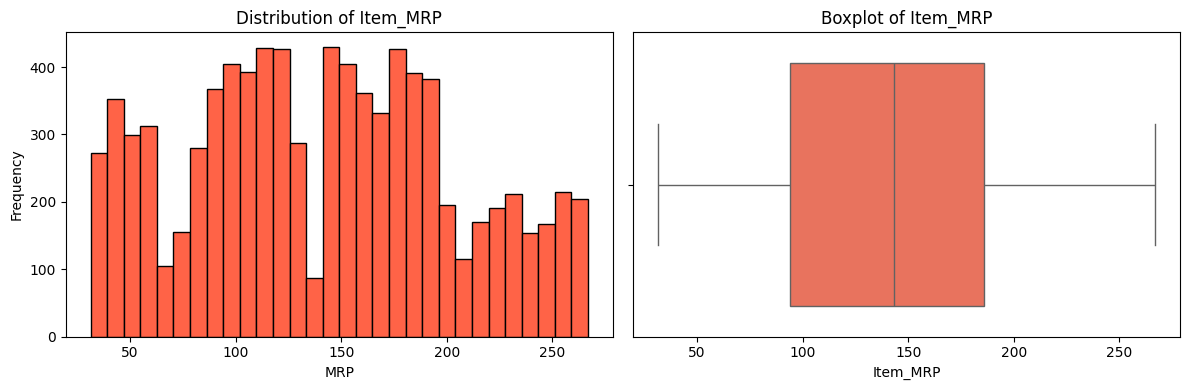

Nulls: 0


In [86]:
# ── Univariate visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Item_MRP'], bins=30, color='tomato', edgecolor='black')
axes[0].set_title('Distribution of Item_MRP')
axes[0].set_xlabel('MRP')
axes[0].set_ylabel('Frequency')

sns.boxplot(x=df['Item_MRP'], ax=axes[1], color='tomato')
axes[1].set_title('Boxplot of Item_MRP')
plt.tight_layout()
plt.savefig('feat_Item_MRP_univariate.png')
plt.show()

print(f"Nulls: {df['Item_MRP'].isnull().sum()}")

### Univariate inspection – `Item_MRP`

| Question | Answer |
|---|---|
| **Type** | Numeric – Continuous |
| **Null values** | 0 (0 %) |
| **Constant / quasi-constant?** | No – wide range |
| **Cardinality** | Continuous – N/A |
| **Known before target?** | Yes |
| **Business reason to exclude?** | No – price is a primary demand driver |

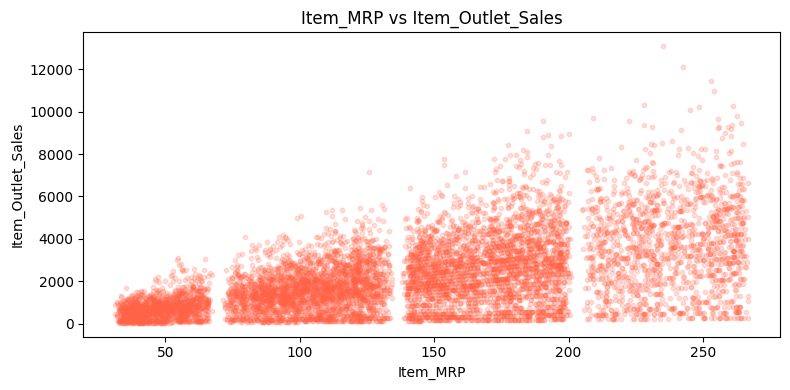

In [87]:
# ── Multivariate: scatter vs sales ────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.scatter(df['Item_MRP'], df['Item_Outlet_Sales'], alpha=0.2, color='tomato', s=10)
plt.title('Item_MRP vs Item_Outlet_Sales')
plt.xlabel('Item_MRP')
plt.ylabel('Item_Outlet_Sales')
plt.tight_layout()
plt.savefig('feat_Item_MRP_multivariate.png')
plt.show()

### Multivariate inspection – `Item_MRP`

| Question | Answer |
|---|---|
| **Expected to predict sales?** | Yes – higher-priced items tend to generate more revenue per unit |
| **Does it appear to predict sales?** | **Yes** – clear positive linear relationship visible |
| **Decision** | **Keep** – strong predictor; no transformation needed |

---
## Feature 7 – `Outlet_Identifier`

**Data Dictionary:**  
Unique ID for each store (e.g. `OUT049`, `OUT018`). A nominal categorical feature.

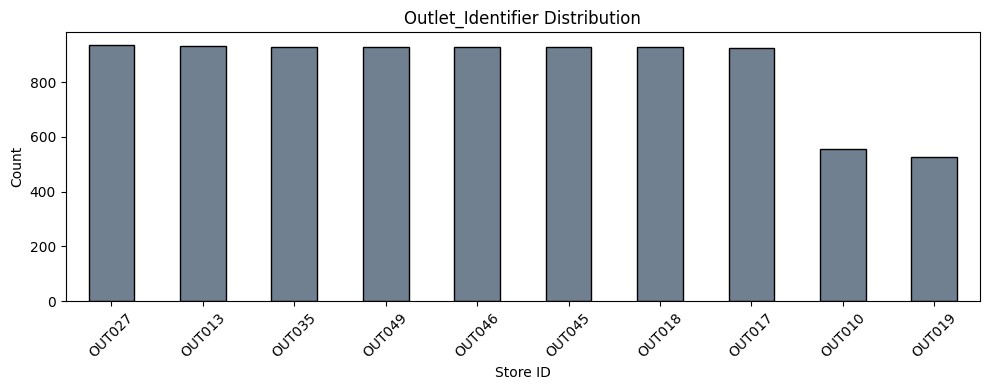

Unique stores: 10
Nulls: 0


In [88]:
# ── Univariate visualisation ──────────────────────────────────────────────
df['Outlet_Identifier'].value_counts().plot(kind='bar', color='slategray',
                                              edgecolor='black', figsize=(10, 4))
plt.title('Outlet_Identifier Distribution')
plt.xlabel('Store ID')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('feat_Outlet_Identifier_univariate.png')
plt.show()

print(f"Unique stores: {df['Outlet_Identifier'].nunique()}")
print(f"Nulls: {df['Outlet_Identifier'].isnull().sum()}")

### Univariate inspection – `Outlet_Identifier`

| Question | Answer |
|---|---|
| **Type** | Categorical – Nominal |
| **Null values** | 0 (0 %) |
| **Constant / quasi-constant?** | No |
| **Cardinality** | 10 – borderline HIGH |
| **Known before target?** | Yes |
| **Business reason to exclude?** | Possibly – it is essentially a surrogate for store-level properties already captured by other features (Outlet_Type, Outlet_Size, etc.). Risk of data leakage if used as-is. |

/tmp/ipykernel_2703/3740463202.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outlet_Identifier', y='Item_Outlet_Sales', data=df,


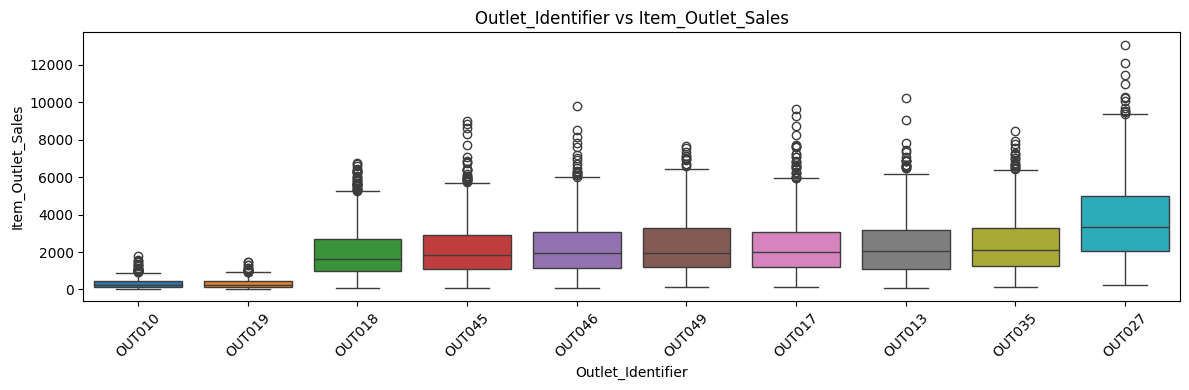

In [89]:
# ── Multivariate: box plot vs sales ───────────────────────────────────────
plt.figure(figsize=(12, 4))
order = df.groupby('Outlet_Identifier')['Item_Outlet_Sales'].median().sort_values().index
sns.boxplot(x='Outlet_Identifier', y='Item_Outlet_Sales', data=df,
            order=order, palette='tab10')
plt.title('Outlet_Identifier vs Item_Outlet_Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('feat_Outlet_Identifier_multivariate.png')
plt.show()

### Multivariate inspection – `Outlet_Identifier`

| Question | Answer |
|---|---|
| **Expected to predict sales?** | Yes – different stores have very different sales volumes |
| **Does it appear to predict sales?** | **Yes** – large median differences across stores |
| **Decision** | **Consider excluding** in favour of more generalisable store properties; or encode with target-encoding if kept |

---
## Feature 8 – `Outlet_Establishment_Year`

**Data Dictionary:**  
The year in which the store was established. A numeric (ordinal) feature. Often engineered into **Outlet Age** = 2023 − Establishment Year.

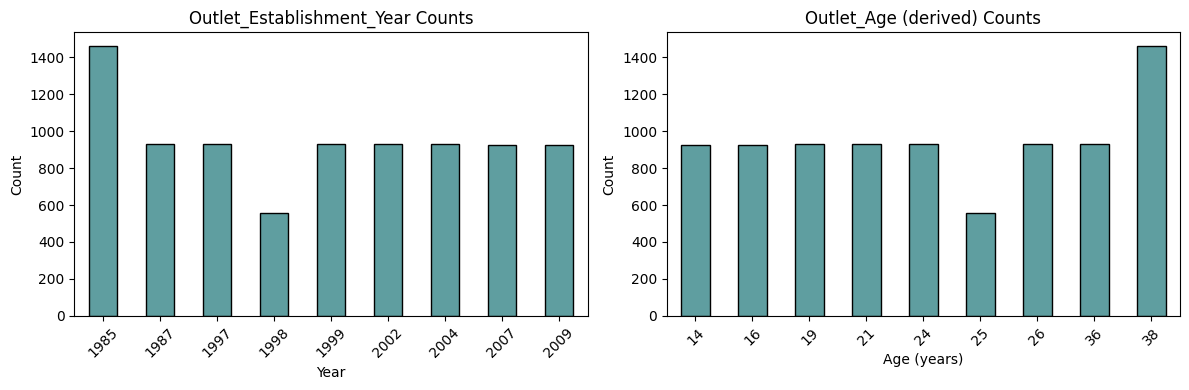

Nulls: 0


In [90]:
# ── Engineer Outlet_Age ───────────────────────────────────────────────────
df['Outlet_Age'] = 2023 - df['Outlet_Establishment_Year']

# ── Univariate visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Outlet_Establishment_Year'].value_counts().sort_index().plot(kind='bar',
    color='cadetblue', edgecolor='black', ax=axes[0])
axes[0].set_title('Outlet_Establishment_Year Counts')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

df['Outlet_Age'].value_counts().sort_index().plot(kind='bar',
    color='cadetblue', edgecolor='black', ax=axes[1])
axes[1].set_title('Outlet_Age (derived) Counts')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('feat_Outlet_Establishment_Year_univariate.png')
plt.show()

print(f"Nulls: {df['Outlet_Establishment_Year'].isnull().sum()}")

### Univariate inspection – `Outlet_Establishment_Year`

| Question | Answer |
|---|---|
| **Type** | Numeric – Ordinal (discrete year) |
| **Null values** | 0 (0 %) |
| **Constant / quasi-constant?** | No – 9 distinct years |
| **Cardinality** | 9 |
| **Known before target?** | Yes |
| **Business reason to exclude?** | No – older stores may have loyal customer bases |

/tmp/ipykernel_2703/2489379848.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outlet_Age', y='Item_Outlet_Sales', data=df, order=order, palette='Blues')


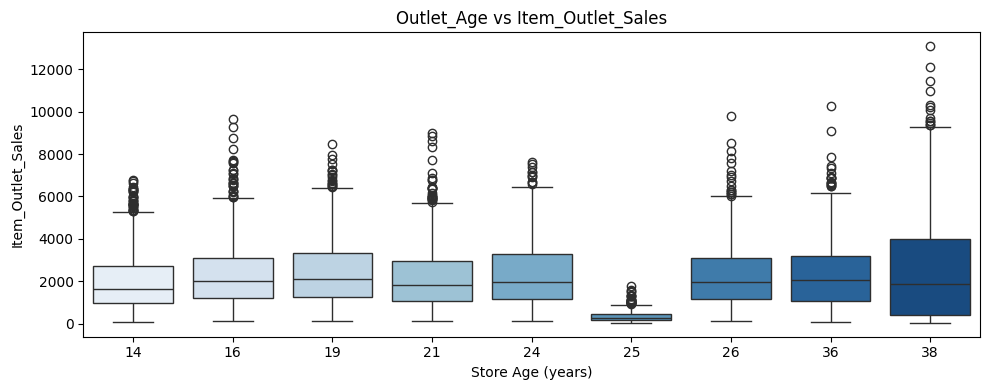

In [91]:
# ── Multivariate: Outlet_Age vs sales ─────────────────────────────────────
plt.figure(figsize=(10, 4))
order = sorted(df['Outlet_Age'].unique())
sns.boxplot(x='Outlet_Age', y='Item_Outlet_Sales', data=df, order=order, palette='Blues')
plt.title('Outlet_Age vs Item_Outlet_Sales')
plt.xlabel('Store Age (years)')
plt.tight_layout()
plt.savefig('feat_Outlet_Establishment_Year_multivariate.png')
plt.show()

### Multivariate inspection – `Outlet_Establishment_Year`

| Question | Answer |
|---|---|
| **Expected to predict sales?** | Possibly – established stores may have higher or lower sales |
| **Does it appear to predict sales?** | Some variation; not a strong monotonic trend |
| **Decision** | **Keep as Outlet_Age** – the engineered feature is more interpretable |

---
## Feature 9 – `Outlet_Size`

**Data Dictionary:**  
The size of the store: `Small`, `Medium`, or `High`. An ordinal categorical feature.

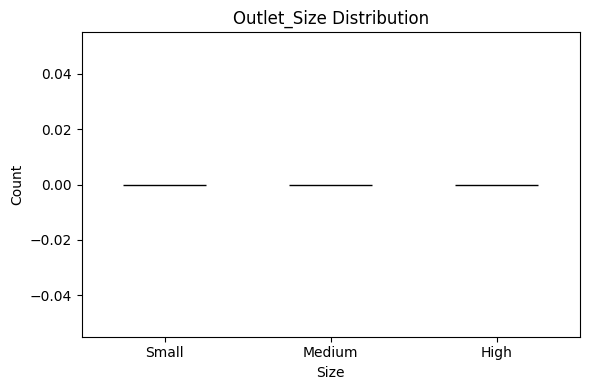

Nulls: 8523 (100.0%)


In [92]:
# ── Univariate visualisation ──────────────────────────────────────────────
size_order = ['Small', 'Medium', 'High']
vc = df['Outlet_Size'].value_counts().reindex(size_order, fill_value=0)
vc.plot(kind='bar', color=['#90CAF9','#42A5F5','#1565C0'],
        edgecolor='black', figsize=(6, 4))
plt.title('Outlet_Size Distribution')
plt.xlabel('Size')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('feat_Outlet_Size_univariate.png')
plt.show()

nulls = df['Outlet_Size'].isnull().sum()
pct   = nulls / len(df) * 100
print(f"Nulls: {nulls} ({pct:.1f}%)")

### Univariate inspection – `Outlet_Size`

| Question | Answer |
|---|---|
| **Type** | Categorical – Ordinal |
| **Null values** | ~2 410 (~28 %) |
| **How to handle nulls?** | **Impute with mode grouped by Outlet_Type** – size is related to store type |
| **Constant / quasi-constant?** | No |
| **Cardinality** | 3 – LOW |
| **Known before target?** | Yes |
| **Business reason to exclude?** | No |

---
## Feature 10 – Outlet_Location_Type

**Data Dictionary:**  
The tier of the city where the store is located: Tier 1, Tier 2, Tier 3. An ordinal categorical feature (Tier 1 = most urbanised).

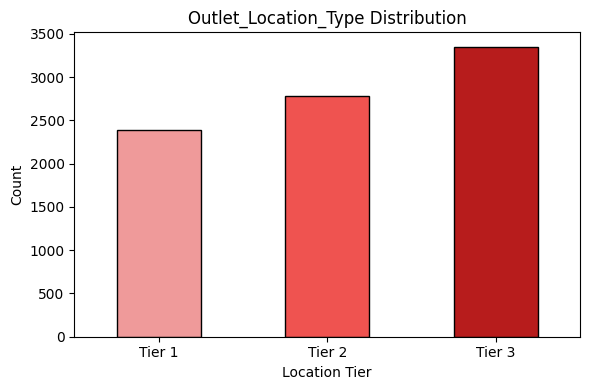

Nulls: 0


In [93]:
# ── Univariate visualisation ──────────────────────────────────────────────
df['Outlet_Location_Type'].value_counts().sort_index().plot(
    kind='bar', color=['#EF9A9A','#EF5350','#B71C1C'], edgecolor='black', figsize=(6, 4))
plt.title('Outlet_Location_Type Distribution')
plt.xlabel('Location Tier')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('feat_Outlet_Location_Type_univariate.png')
plt.show()

print(f"Nulls: {df['Outlet_Location_Type'].isnull().sum()}")

### Univariate inspection – Outlet_Location_Type

| Question | Answer |
|---|---|
| **Type** | Categorical – Ordinal |
| **Null values** | 0 (0 %) |
| **Constant / quasi-constant?** | No |
| **Cardinality** | 3 – LOW |
| **Known before target?** | Yes |
| **Business reason to exclude?** | No |

/tmp/ipykernel_2703/2279218359.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outlet_Location_Type', y='Item_Outlet_Sales', data=df, palette='Reds');


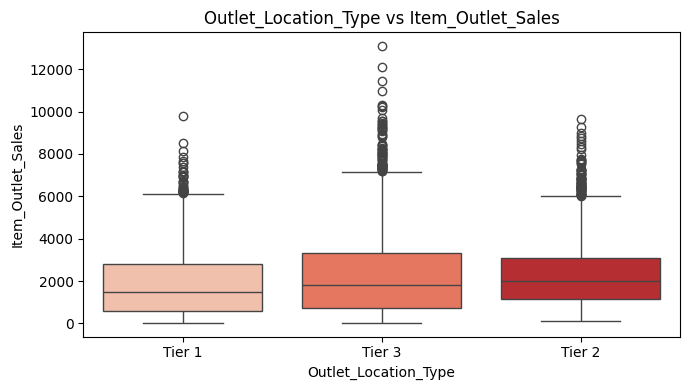

In [94]:
# ── Multivariate: box plot vs sales ───────────────────────────────────────
plt.figure(figsize=(7, 4))
sns.boxplot(x='Outlet_Location_Type', y='Item_Outlet_Sales', data=df, palette='Reds');
plt.title('Outlet_Location_Type vs Item_Outlet_Sales');
plt.tight_layout();
plt.savefig('feat_Outlet_Location_Type_multivariate.png');
plt.show()

### Multivariate inspection –Outlet_Location_Type

| Question | Answer |
|---|---|
| **Expected to predict sales?** | Yes – purchasing power differs by city tier |
| **Does it appear to predict sales?** | Yes – Tier 3 outlets show notably different distributions |
| **Decision** | **Keep** – ordinal encode (Tier 1=1, Tier 2=2, Tier 3=3) |

---
## Feature 11 – Outlet_Type

**Data Dictionary:**  
The type of store: `Grocery Store`, `Supermarket Type1`, `Supermarket Type2`, `Supermarket Type3`. A nominal categorical feature.

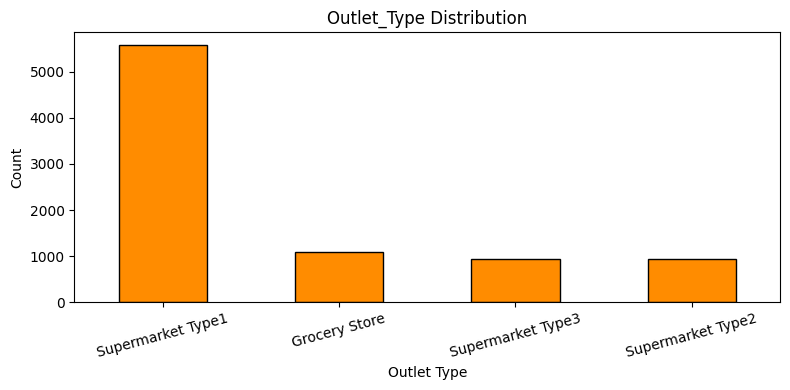

Nulls: 0


In [95]:
# ── Univariate visualisation ──────────────────────────────────────────────
df['Outlet_Type'].value_counts().plot(kind='bar', color='darkorange',
                                       edgecolor='black', figsize=(8, 4))
plt.title('Outlet_Type Distribution')
plt.xlabel('Outlet Type')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('feat_Outlet_Type_univariate.png')
plt.show()

print(f"Nulls: {df['Outlet_Type'].isnull().sum()}")

### Univariate inspection – Outlet_Type

| Question | Answer |
|---|---|
| **Type** | Categorical – Nominal |
| **Null values** | 0 (0 %) |
| **Constant / quasi-constant?** | No |
| **Cardinality** | 4 – LOW |
| **Known before target?** | Yes |
| **Business reason to exclude?** | No |

/tmp/ipykernel_2703/3922352064.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outlet_Type', y='Item_Outlet_Sales', data=df,


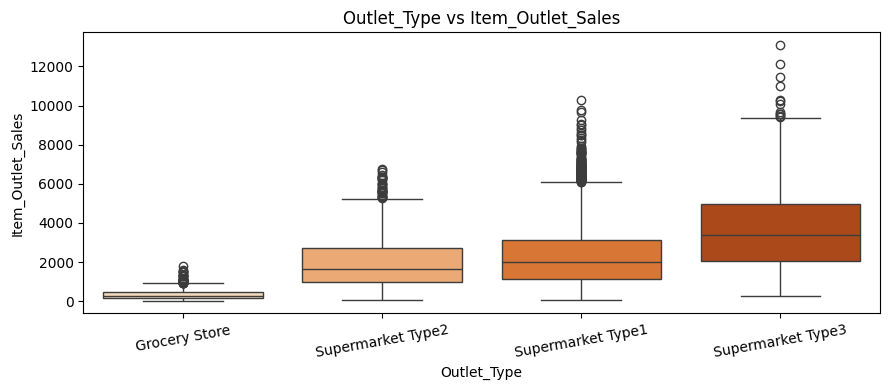

In [96]:
# ── Multivariate: box plot vs sales ───────────────────────────────────────
plt.figure(figsize=(9, 4))
order = df.groupby('Outlet_Type')['Item_Outlet_Sales'].median().sort_values().index
sns.boxplot(x='Outlet_Type', y='Item_Outlet_Sales', data=df,
            order=order, palette='Oranges')
plt.title('Outlet_Type vs Item_Outlet_Sales')
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('feat_Outlet_Type_multivariate.png')
plt.show()

### Multivariate inspection – Outlet_Type

| Question | Answer |
|---|---|
| **Expected to predict sales?** | **Yes** – supermarkets have far higher foot-traffic than grocery stores |
| **Does it appear to predict sales?** | **Yes** – largest median difference of all features |
| **Decision** | **Keep** – one-hot encode; strong predictor |

---
## Part 4 – Feature Inspection Summary

| Feature | Type | Nulls | Cardinality | Action |
|---|---|---|---|---|
| `Item_Identifier` | Nominal | 0 | HIGH | **Drop** – unique ID, no predictive value |
| `Item_Weight` | Numeric | ~17 % | Continuous | **Keep** – impute with median |
| `Item_Fat_Content` | Nominal | 0 | 2 | **Keep** – label encode |
| `Item_Visibility` | Numeric | 0 (zeros ~13%) | Continuous | **Keep** – replace zeros → NaN, impute |
| `Item_Type` | Nominal | 0 | 16 | **Keep** – group or one-hot encode |
| `Item_MRP` | Numeric | 0 | Continuous | **Keep** – strong linear predictor |
| `Outlet_Identifier` | Nominal | 0 | 10 | **Consider dropping** – store properties captured by other features |
| `Outlet_Establishment_Year` | Numeric/Ordinal | 0 | 9 | **Keep as Outlet_Age** |
| `Outlet_Size` | Ordinal | ~28 % | 3 | **Keep** – impute by Outlet_Type mode |
| `Outlet_Location_Type` | Ordinal | 0 | 3 | **Keep** – ordinal encode |
| `Outlet_Type` | Nominal | 0 | 4 | **Keep** – strongest categorical predictor |

> **Target:** Item_Outlet_Sales (continuous, right-skewed) – consider log-transform before modelling.

In [97]:
import os, shutil

os.makedirs('images', exist_ok=True)

plots = [
    'heatmap.png',
    'histogram.png',
    'boxplot.png',
    'countplot.png',
    'feat_Item_MRP_multivariate.png',
    'feat_Item_MRP_univariate.png',
    'feat_Outlet_Type_multivariate.png',
    'feat_Outlet_Type_univariate.png',
    'feat_Item_Type_multivariate.png',
    'feat_Item_Type_univariate.png',
    'feat_Outlet_Location_Type_multivariate.png',
    'feat_Outlet_Location_Type_univariate.png',
    'feat_Item_Fat_Content_multivariate.png',
    'feat_Item_Fat_Content_univariate.png',
    'feat_Item_Weight_multivariate.png',
    'feat_Item_Weight_univariate.png',
    'feat_Item_Visibility_multivariate.png',
    'feat_Item_Visibility_univariate.png',
    'feat_Item_Identifier_univariate.png',
    'feat_Outlet_Identifier_multivariate.png',
    'feat_Outlet_Identifier_univariate.png',
    'feat_Outlet_Size_univariate.png',
    'feat_Outlet_Establishment_Year_multivariate.png',
]

moved = []
for f in plots:
    if os.path.exists(f):
        shutil.move(f, f'images/{f}')
        moved.append(f)

print(f"✅ Moved {len(moved)} images to images/")
print("Files:", moved)


✅ Moved 23 images to images/
Files: ['heatmap.png', 'histogram.png', 'boxplot.png', 'countplot.png', 'feat_Item_MRP_multivariate.png', 'feat_Item_MRP_univariate.png', 'feat_Outlet_Type_multivariate.png', 'feat_Outlet_Type_univariate.png', 'feat_Item_Type_multivariate.png', 'feat_Item_Type_univariate.png', 'feat_Outlet_Location_Type_multivariate.png', 'feat_Outlet_Location_Type_univariate.png', 'feat_Item_Fat_Content_multivariate.png', 'feat_Item_Fat_Content_univariate.png', 'feat_Item_Weight_multivariate.png', 'feat_Item_Weight_univariate.png', 'feat_Item_Visibility_multivariate.png', 'feat_Item_Visibility_univariate.png', 'feat_Item_Identifier_univariate.png', 'feat_Outlet_Identifier_multivariate.png', 'feat_Outlet_Identifier_univariate.png', 'feat_Outlet_Size_univariate.png', 'feat_Outlet_Establishment_Year_multivariate.png']
